# GIIP: Predictive Modeling & Pipeline


This notebook demonstrates the machine learning pipeline, strictly avoiding temporal data leakage through walk-forward validation and careful feature engineering.


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Feature Engineering & Leakage Prevention


When forecasting 2025 demand, we cannot use 2025 demographic actuals (as they haven't happened yet). We must strictly `.shift()` our features by 1 year to simulate real-world prediction conditions.


In [2]:
df = pd.read_csv('../data/vaccine_data.csv')

# Sort chronologically to prevent temporal mixing
df = df.sort_values(['Country', 'Year'])

# Create lagged features
features = ['Births (thousands)', 'Infant Deaths, under age 1 (thousands)']
for f in features:
    df[f'Lag_{f}'] = df.groupby('Country')[f].shift(1)

# Drop NaN rows created by the shift
df_clean = df.dropna(subset=[f'Lag_{f}' for f in features]).copy()
display(df_clean[['Country', 'Year', 'MCV1_TARGET'] + [f'Lag_{f}' for f in features]].head())

,Country,Year,MCV1_TARGET,Lag_Births (thousands),"Lag_Infant Deaths, under age 1 (thousands)"
109,Kyrgyzstan,1993,160.872020,139.610,7.157
108,Kyrgyzstan,1994,143.956853,132.994,6.806
107,Kyrgyzstan,1995,156.562527,124.509,6.305
106,Kyrgyzstan,1996,157.830307,125.889,6.135
105,Kyrgyzstan,1997,151.884973,121.676,5.830


## 2. Walk-Forward Validation (Time-based Split)


Random train/test splits (like K-Fold) are fundamentally flawed for time-series data. We must train on the past (e.g., < 2020) and test on the future (>= 2020) to prove the model actually generalizes to unseen future trends.


In [3]:
train = df_clean[df_clean['Year'] < 2020]
test = df_clean[df_clean['Year'] >= 2020]

X_cols = [f'Lag_{f}' for f in features]

X_train, y_train = train[X_cols], train['MCV1_TARGET']
X_test, y_test = test[X_cols], test['MCV1_TARGET']

print(f'Training records: {len(train)}\nTesting records: {len(test)}')

Training records: 93
Testing records: 15


## 3. Model Training & Evaluation


We select **Huber Regressor** over standard OLS (Linear Regression) because Huber's loss function is mathematically robust to outliers. It prevents massive one-off anomalies (like pandemic drops) from skewing the regression line.


In [4]:
model = HuberRegressor(epsilon=1.35)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, preds)
print(f'Model Test MAPE: {mape:.2%}')

Model Test MAPE: 4.19%


## 4. Feature Importance Insights


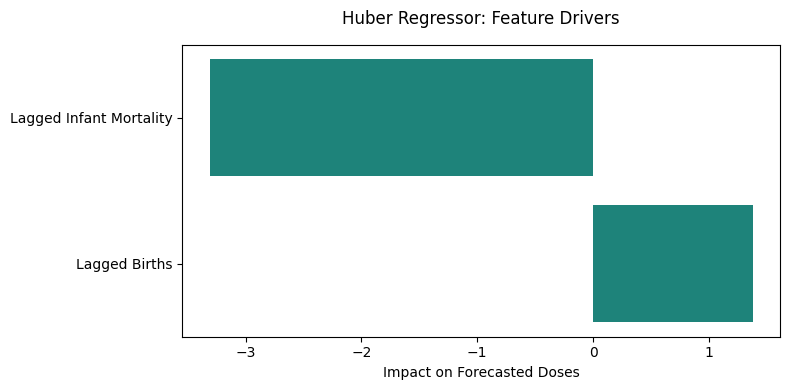

In [5]:
importance = pd.DataFrame({'Feature': ['Lagged Births', 'Lagged Infant Mortality'], 'Coefficient': model.coef_})
importance = importance.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance, x='Coefficient', y='Feature', color='#0d9488')
plt.title('Huber Regressor: Feature Drivers', pad=15)
plt.xlabel('Impact on Forecasted Doses')
plt.ylabel('')
plt.tight_layout()
plt.show()